### 傳統 ML 模型訓練與比較

In [8]:
import pandas as pd
df = pd.read_csv('../data/cleaned_encoded_data.csv')

In [9]:
# Split Features and Target
X = df.drop(columns=['no_show'])
y = df['no_show']


In [12]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42) # Stratify to maintain the distribution of the target variable in both train and test sets


In [ ]:
# Fix Imbalance data using SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print(y_train_balanced.value_counts())

Before SMOTE:
no_show
0    27609
1     3076
Name: count, dtype: int64
After SMOTE:
no_show
0    27609
1    27609
Name: count, dtype: int64


### Model Training 
#### 1. Logistic Regression
#### 2. Decision Tree
#### 3. Random Forest 

In [17]:
### Start with Basic Logistic Regression Model 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [20]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

In [21]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train_balanced)

LogisticRegression(max_iter=1000, random_state=42)

In [22]:
y_pred = logreg.predict(X_test_scaled)
y_pred_proba = logreg.predict_proba(X_test_scaled)[:, 1]

#### Evaluation Metrics:
1. Accuracy = (TP + TN) / (TP + FP + TN + FN) 
2. Precision = TP / (TP + FN) 
3. Recall = TP / (TP + EN) -> 成功預測出來的比例
4. F1 Score = 2 * (Precision + Recall) / (Precision + Recall) 
5. ROC AUC

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

# Print scores
# Accuracy will be less applicable since we have an highly imbalanced dataset
print("Logistic Regression Evaluation:")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_proba)) 

Logistic Regression Evaluation:
Accuracy : 0.8899026763990268
Precision: 0.20454545454545456
Recall   : 0.03414264036418816
F1 Score : 0.05851755526657997
ROC AUC  : 0.585642357108437


Confusion Matrix:


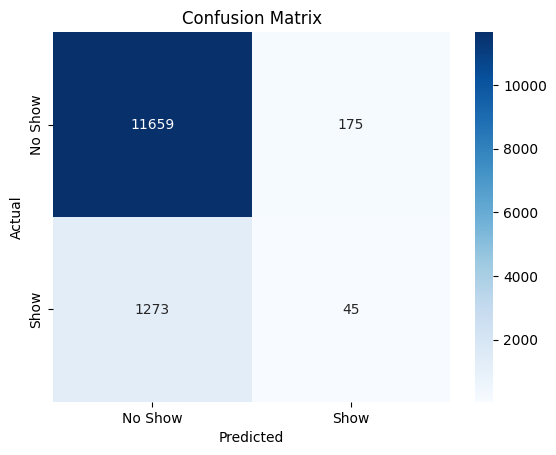

In [24]:
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Show', 'Show'], yticklabels=['No Show', 'Show'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### The performance of simple Logistric Regression is bad based on:
1. Low Precision 0.2 -> Of all predicted "no-shows", only 20% were truly no-shows
2. Low Recall 0.034 -> Model found only 3.4% of all actual no-shows
3. Low F1 Score  0.058 -> Balance between precision & recall — quite low
4. Low ROC AUC: 0.585 -> Barely better than random guessing (0.5 is random)

### Try Random Forest 

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=None,          # allow trees to grow fully
    random_state=42,
    class_weight=None        # SMOTE already handled imbalance
)

rf_model.fit(X_train_balanced, y_train_balanced)


RandomForestClassifier(random_state=42)

In [27]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]  # needed for AUC

Random Forest Evaluation:
Accuracy : 0.8827554744525548
Precision: 0.30350877192982456
Recall   : 0.13125948406676782
F1 Score : 0.1832627118644068
ROC AUC  : 0.6782375273221907


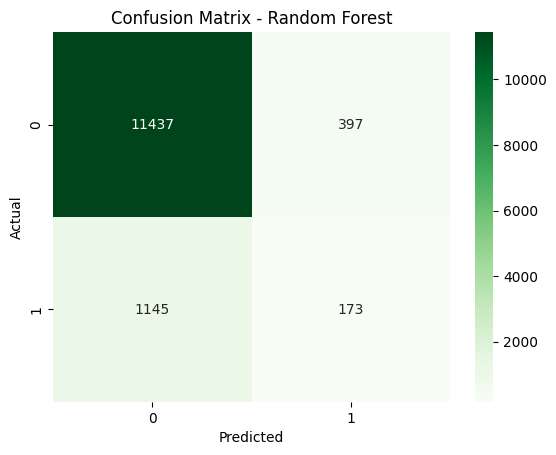

In [28]:
# Print metrics
print("Random Forest Evaluation:")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_proba_rf))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],         # number of trees
    'max_depth': [10, 20, None],        # how deep each tree can grow
    'min_samples_split': [2, 5],        # min samples to split a node
    'max_features': ['sqrt', 'log2']    # features per split
}
grid = GridSearchCV(rf_model, 
              param_grid,
              scoring='recall',
              cv=5, 
              n_jobs=-1, 
              verbose=2
              )

In [32]:
grid.fit(X_train_balanced, y_train_balanced)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   2.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   3.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   3.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   3.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   3.1s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   4.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   4.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   4.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   2.4s
[CV] END max_depth=10, max_features=sq

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='recall', verbose=2)

Best parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.91      0.97      0.94     11834
           1       0.31      0.13      0.18      1318

    accuracy                           0.88     13152
   macro avg       0.61      0.55      0.56     13152
weighted avg       0.85      0.88      0.86     13152

Confusion Matrix:


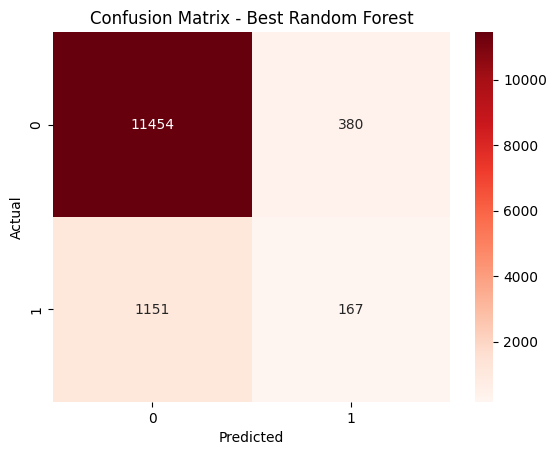

Accuracy: 0.8835918491484185
Precision: 0.3053016453382084
Recall: 0.1267071320182094
F1 Score: 0.17908847184986595
ROC AUC: 0.6863522147419681


In [33]:
best_rf = grid.best_estimator_

print("Best parameters:", grid.best_params_)

# Predict on test set
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

# Evaluate
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred_best))
print("Confusion Matrix:")
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix - Best Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1 Score:", f1_score(y_test, y_pred_best))
print("ROC AUC:", roc_auc_score(y_test, y_proba_best))


In [34]:
# Predict probabilities
y_proba = best_rf.predict_proba(X_test)[:, 1]

# Set a custom threshold (e.g., 0.3 instead of 0.5)
threshold = 0.3
y_pred_custom = (y_proba >= threshold).astype(int)

# Re-evaluate
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.92      0.91      0.92     11834
           1       0.27      0.29      0.28      1318

    accuracy                           0.85     13152
   macro avg       0.59      0.60      0.60     13152
weighted avg       0.85      0.85      0.85     13152

